In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
import seaborn as sns
import kagglehub

C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.dataset_download("florianhinrichsen/nyc-taxi-data-2023-24")

PUs_df = pd.read_parquet(f"{path}\hourlyPUs2023-24WEATHER.parquet")
DOs_df = pd.read_parquet(f"{path}\hourlyDOs2023-24WEATHER.parquet")

DOs_df = DOs_df[(DOs_df["year"] >= 2023) & (DOs_df["year"] <= 2024)]

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 20
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["figure.dpi"] = 50

### Trip count

Trip count per month

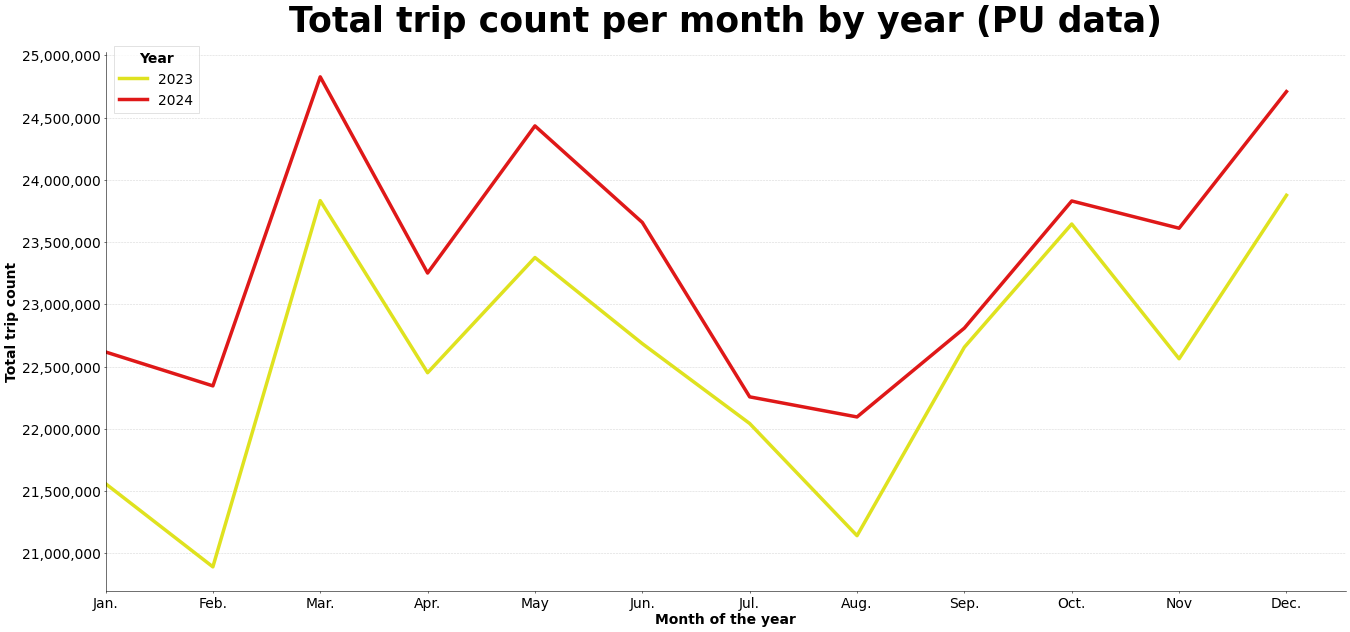

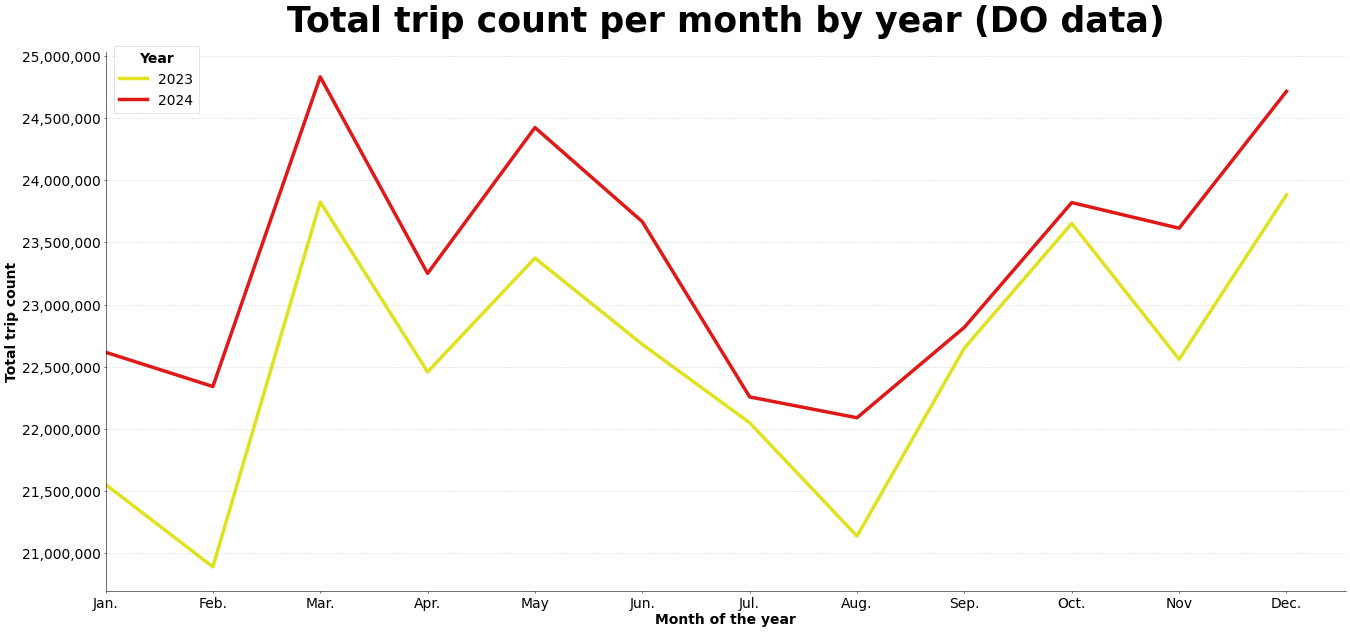

In [20]:
month_PUs = PUs_df.groupby(["year","month"])["trip_count"].sum().reset_index()
month_DOs = DOs_df.groupby(["year","month"])["trip_count"].sum().reset_index()


fig, ax = plt.subplots(figsize=(32, 14))

sns.lineplot(
    data=month_PUs, 
    x="month", 
    y="trip_count", 
    hue="year", 
    palette=["#DFE21F", "#DF1818"],
    linewidth=5,
    ax=ax
)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

plt.title("Total trip count per month by year (PU data)",
          fontsize=50, fontweight="bold",pad=30)
plt.grid(axis="y",linestyle="--", alpha=0.5)
plt.xlabel("Month of the year", fontweight="bold")
plt.ylabel("Total trip count", fontweight="bold")
plt.xticks(range(1, 13),labels=
           ["Jan.","Feb.","Mar.","Apr.","May","Jun.","Jul.","Aug.","Sep.","Oct.","Nov","Dec."])
plt.xlim(left=1)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles=handles,
    labels=labels,
    title="Year",
    title_fontproperties={"weight":"bold"},
    loc="upper left",
    bbox_to_anchor=(0.001,1.025),
    fancybox=False
)

plt.savefig("Plots\TimeSeries\TripCount\PUsTripCountperMonthly.png",dpi=300)
plt.show()


fig, ax = plt.subplots(figsize=(32, 14))

sns.lineplot(
    data=month_DOs, 
    x="month", 
    y="trip_count", 
    hue="year", 
    palette=["#DFE21F", "#DF1818"],
    linewidth=5,
    ax=ax
)

ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

plt.title("Total trip count per month by year (DO data)",
          fontsize=50, fontweight="bold",pad=30)
plt.grid(axis="y",linestyle="--", alpha=0.5)
plt.xlabel("Month of the year", fontweight="bold")
plt.ylabel("Total trip count", fontweight="bold")

plt.xticks(range(1, 13),labels=
           ["Jan.","Feb.","Mar.","Apr.","May","Jun.","Jul.","Aug.","Sep.","Oct.","Nov","Dec."])
plt.xlim(left=1)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles=handles,
    labels=labels,
    title="Year",
    title_fontproperties={"weight":"bold"},
    loc="upper left",
    bbox_to_anchor=(0.001,1.025),
    fancybox=False
)

plt.savefig("Plots\TimeSeries\TripCount\DOsTripCountMonthly.png",dpi=300)
plt.show()

Trip count over a 7-day rolling average window

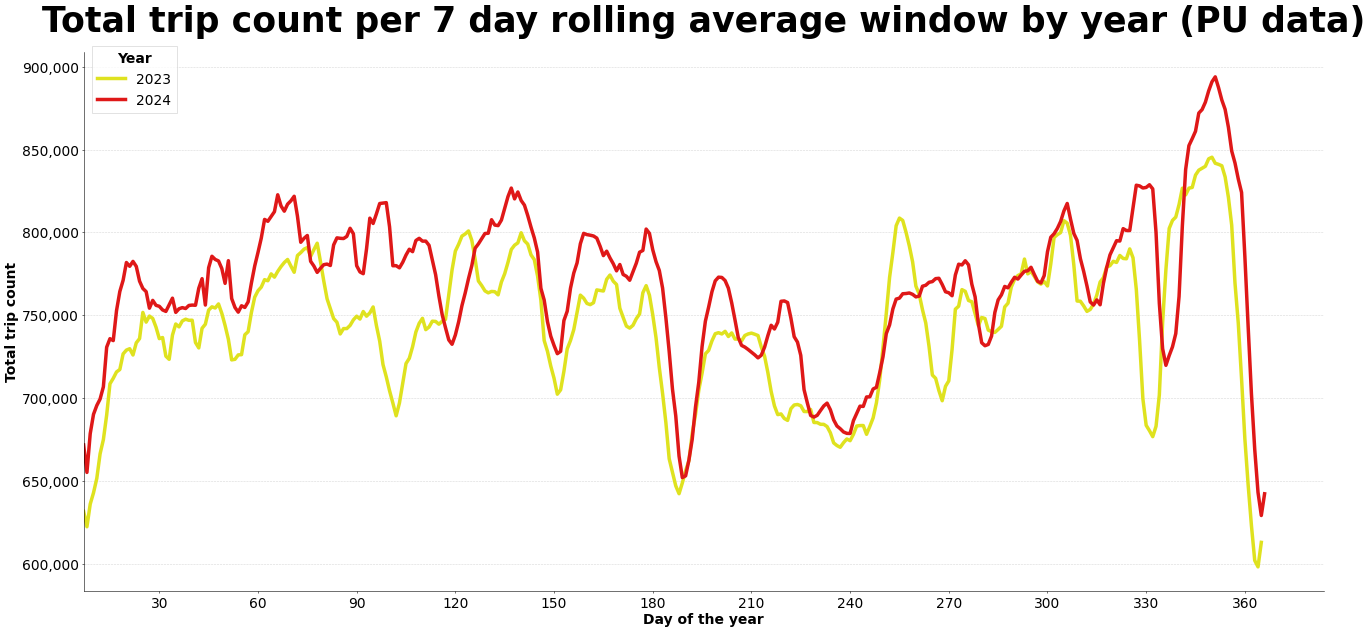

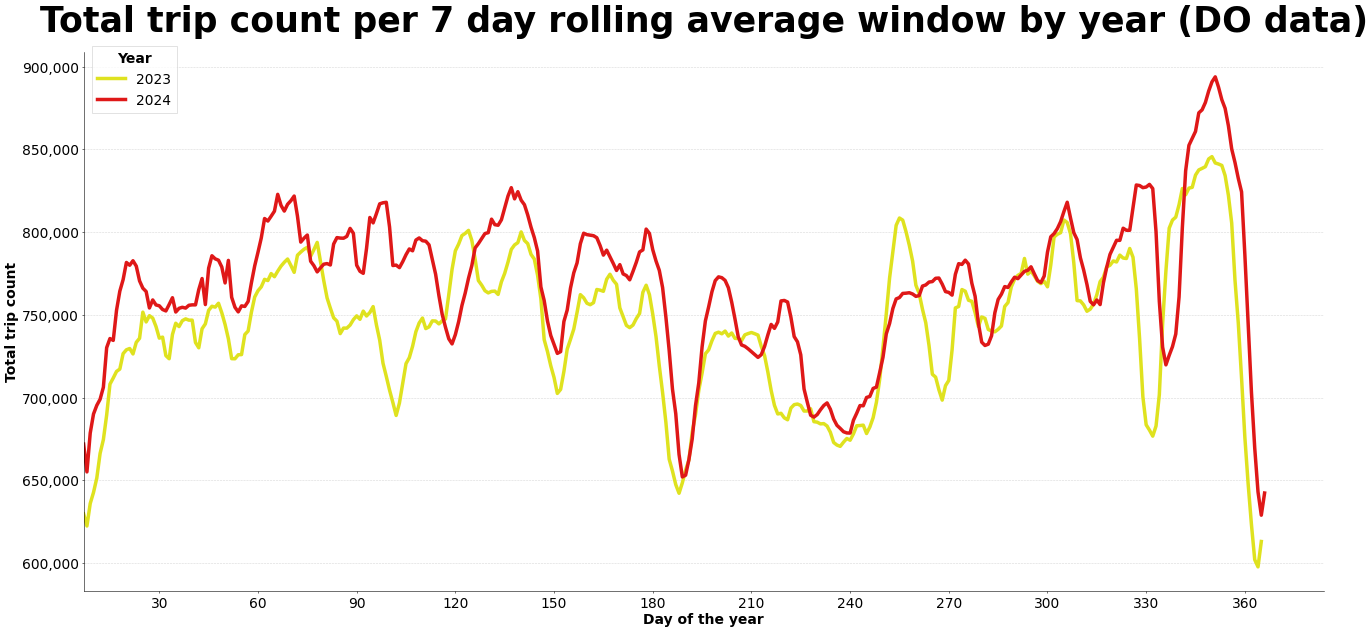

In [ ]:
daily_PUs = PUs_df.groupby(PUs_df["PUhour"].dt.date)["trip_count"].sum().reset_index()
daily_DOs = DOs_df.groupby(DOs_df["DOhour"].dt.date)["trip_count"].sum().reset_index()

daily_PUs["PUhour"] = pd.to_datetime(daily_PUs["PUhour"])
daily_DOs["DOhour"] = pd.to_datetime(daily_DOs["DOhour"])

daily_PUs["year"] = daily_PUs["PUhour"].dt.year
daily_DOs["year"] = daily_DOs["DOhour"].dt.year

daily_PUs["DayOfYear"] = daily_PUs["PUhour"].dt.dayofyear
daily_DOs["DayOfYear"] = daily_DOs["DOhour"].dt.dayofyear

daily_PUs["7dayAVG"] = daily_PUs.groupby(daily_PUs["PUhour"].dt.year)["trip_count"].transform(
    lambda x: x.rolling(window=7).mean()
)

daily_DOs["7dayAVG"] = daily_DOs.groupby(daily_DOs["DOhour"].dt.year)["trip_count"].transform(
    lambda x: x.rolling(window=7).mean()
)


plt.figure(figsize=(32,14))

ax = sns.lineplot(
    data=daily_PUs, 
    x="DayOfYear", 
    y="7dayAVG", 
    hue="year", 
    palette=['#DFE21F', '#DF1818'], 
    linewidth=5
)

ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

plt.title("Total trip count per 7 day rolling average window by year (PU data)",
          fontsize=50, fontweight="bold",pad=30)
plt.grid(axis="y",linestyle="--", alpha=0.5)
plt.xlabel("Day of the year", fontweight="bold")
plt.ylabel("Total trip count", fontweight="bold")
plt.xticks(range(0,366,30))
plt.xlim(left=7)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles=handles,
    labels=labels,
    title="Year",
    title_fontproperties={"weight":"bold"},
    loc="upper left",
    bbox_to_anchor=(0.001,1.025),
    fancybox=False
)


plt.savefig("Plots\TimeSeries\TripCount\PUsTripCount7DayAVG.png",dpi=300)
plt.show()


plt.figure(figsize=(32,14))

ax = sns.lineplot(
    data=daily_DOs, 
    x="DayOfYear", 
    y="7dayAVG", 
    hue="year", 
    palette=['#DFE21F', '#DF1818'], 
    linewidth=5
)

ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

plt.title("Total trip count per 7 day rolling average window by year (DO data)",
          fontsize=50, fontweight="bold",pad=30)
plt.grid(axis="y",linestyle="--", alpha=0.5)
plt.xlabel("Day of the year", fontweight="bold")
plt.ylabel("Total trip count", fontweight="bold")
plt.xticks(range(0,366,30))
plt.xlim(left=7)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles=handles,
    labels=labels,
    title="Year",
    title_fontproperties={"weight":"bold"},
    loc="upper left",
    bbox_to_anchor=(0.001,1.025),
    fancybox=False
)

plt.savefig("Plots\TimeSeries\TripCount\DOsTripCount7DayAVG.png",dpi=300)
plt.show()

### Trip distance

Trip distance per month

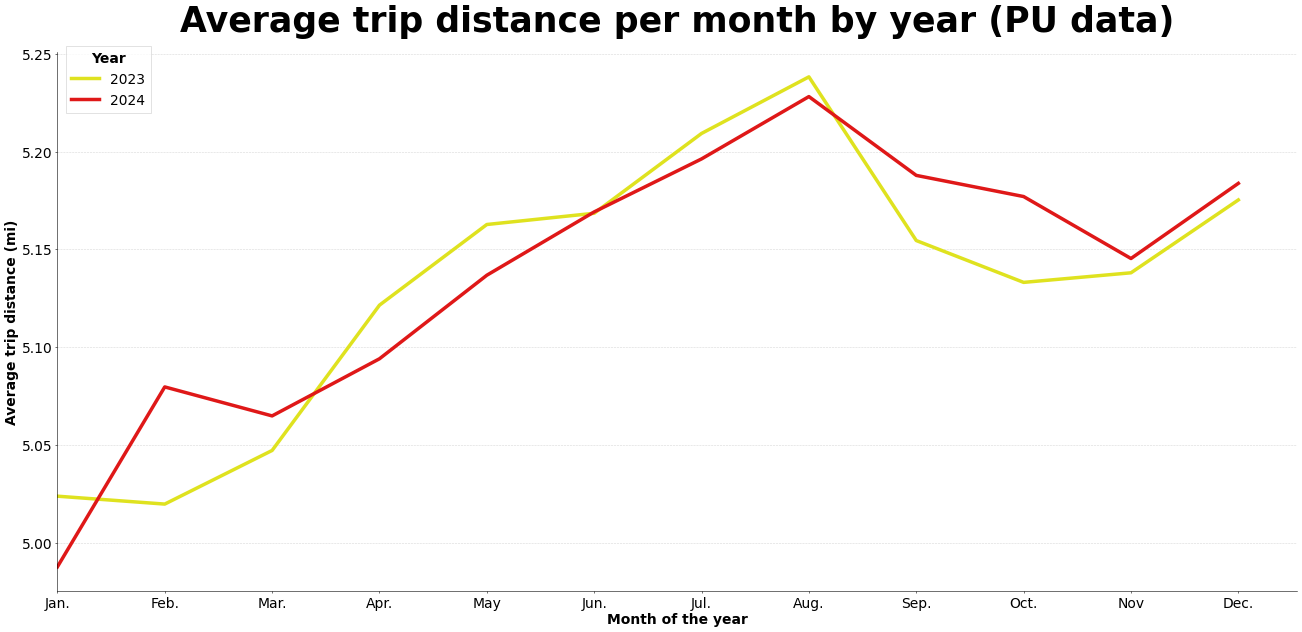

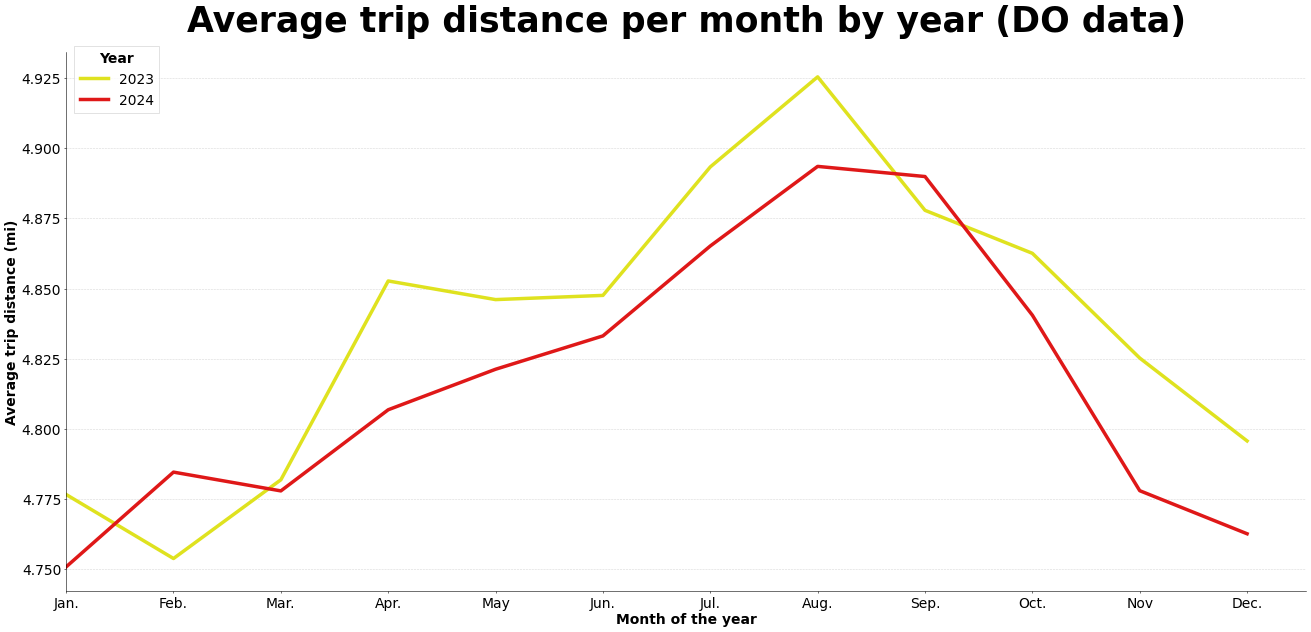

In [ ]:
month_PUs = PUs_df.groupby(["year","month"])["trip_distance"].mean().reset_index()
month_DOs = DOs_df.groupby(["year","month"])["trip_distance"].mean().reset_index()


fig, ax = plt.subplots(figsize=(32, 14))

sns.lineplot(
    data=month_PUs, 
    x="month", 
    y="trip_distance", 
    hue="year", 
    palette=['#DFE21F', '#DF1818'],
    linewidth=5,
    ax=ax
)


plt.title("Average trip distance per month by year (PU data)",
          fontsize=50, fontweight="bold",pad=30)
plt.grid(axis="y",linestyle="--", alpha=0.5)
plt.xlabel("Month of the year", fontweight="bold")
plt.ylabel("Average trip distance (mi)", fontweight="bold")
plt.xticks(range(1, 13),labels=
           ["Jan.","Feb.","Mar.","Apr.","May","Jun.","Jul.","Aug.","Sep.","Oct.","Nov","Dec."])
plt.xlim(left=1)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles=handles,
    labels=labels,
    title="Year",
    title_fontproperties={"weight":"bold"},
    loc="upper left",
    bbox_to_anchor=(0.001,1.025),
    fancybox=False
)


plt.savefig("Plots\TimeSeries\TripDistance\PUsTripDistanceperMonthly.png",dpi=300)
plt.show()


fig, ax = plt.subplots(figsize=(32, 14))

sns.lineplot(
    data=month_DOs, 
    x="month", 
    y="trip_distance", 
    hue="year", 
    palette=['#DFE21F', '#DF1818'],
    linewidth=5,
    ax=ax
)


plt.title("Average trip distance per month by year (DO data)",
          fontsize=50, fontweight="bold",pad=30)
plt.grid(axis="y",linestyle="--", alpha=0.5)
plt.xlabel("Month of the year", fontweight="bold")
plt.ylabel("Average trip distance (mi)", fontweight="bold")
plt.xticks(range(1, 13),labels=
           ["Jan.","Feb.","Mar.","Apr.","May","Jun.","Jul.","Aug.","Sep.","Oct.","Nov","Dec."])
plt.xlim(left=1)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles=handles,
    labels=labels,
    title="Year",
    title_fontproperties={"weight":"bold"},
    loc="upper left",
    bbox_to_anchor=(0.001,1.025),
    fancybox=False
)

plt.savefig("Plots\TimeSeries\TripDistance\DOsTripDistanceMonthly.png",dpi=300)
plt.show()

Trip distance over a 7-day rolling average window

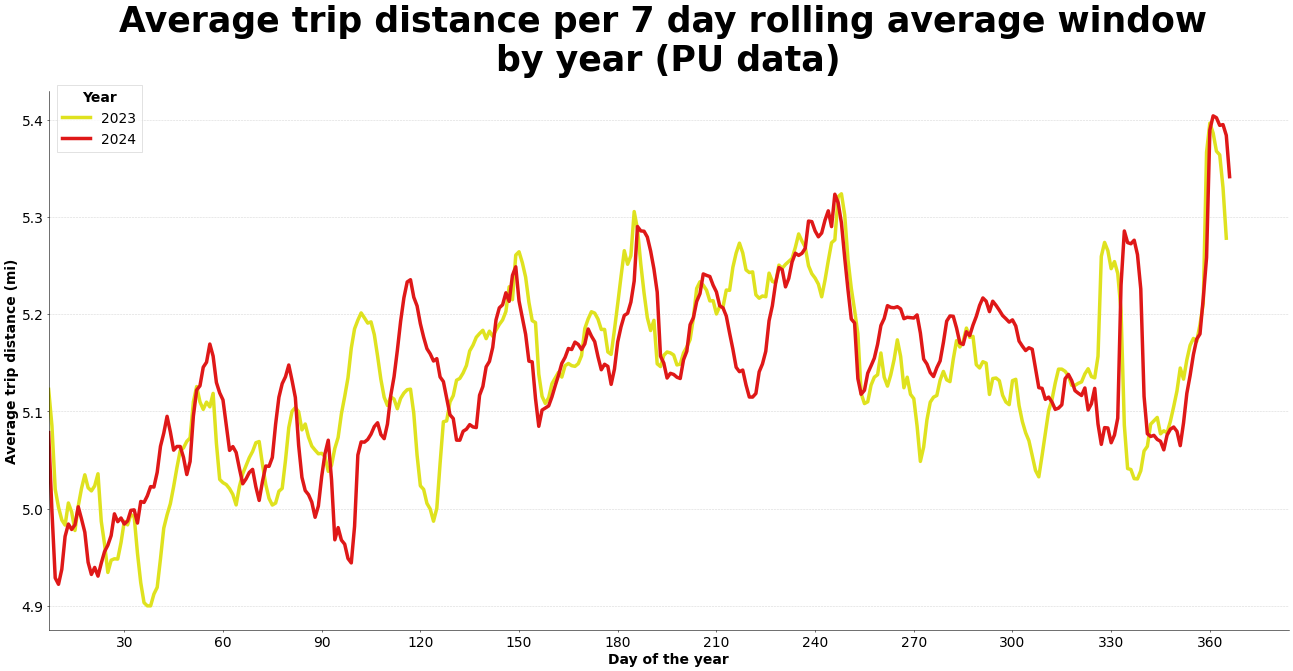

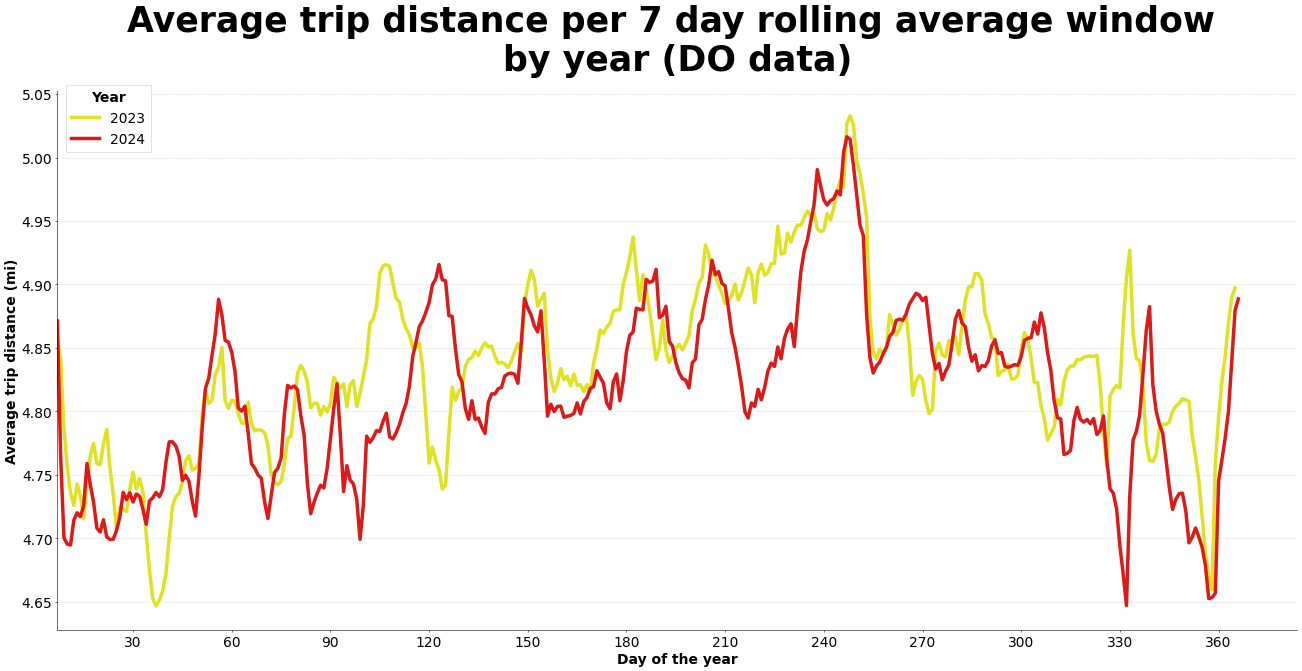

In [ ]:
daily_PUs = PUs_df.groupby(PUs_df["PUhour"].dt.date)["trip_distance"].mean().reset_index()
daily_DOs = DOs_df.groupby(DOs_df["DOhour"].dt.date)["trip_distance"].mean().reset_index()

daily_PUs["PUhour"] = pd.to_datetime(daily_PUs["PUhour"])
daily_DOs["DOhour"] = pd.to_datetime(daily_DOs["DOhour"])

daily_PUs["year"] = daily_PUs["PUhour"].dt.year
daily_DOs["year"] = daily_DOs["DOhour"].dt.year

daily_PUs["DayOfYear"] = daily_PUs["PUhour"].dt.dayofyear
daily_DOs["DayOfYear"] = daily_DOs["DOhour"].dt.dayofyear

daily_PUs["7dayAVG"] = daily_PUs.groupby(daily_PUs["PUhour"].dt.year)["trip_distance"].transform(
    lambda x: x.rolling(window=7).mean()
)

daily_DOs["7dayAVG"] = daily_DOs.groupby(daily_DOs["DOhour"].dt.year)["trip_distance"].transform(
    lambda x: x.rolling(window=7).mean()
)


plt.figure(figsize=(32,14))

ax = sns.lineplot(
    data=daily_PUs, 
    x="DayOfYear", 
    y="7dayAVG", 
    hue="year", 
    palette=['#DFE21F', '#DF1818'], 
    linewidth=5
)

plt.title("Average trip distance per 7 day rolling average window \nby year (PU data)",
          fontsize=50, fontweight="bold",pad=30)
plt.grid(axis="y",linestyle="--", alpha=0.5)
plt.xlabel("Day of the year", fontweight="bold")
plt.ylabel("Average trip distance (mi)", fontweight="bold")
plt.xticks(range(0,366,30))
plt.xlim(left=7)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles=handles,
    labels=labels,
    title="Year",
    title_fontproperties={"weight":"bold"},
    loc="upper left",
    bbox_to_anchor=(0.001,1.025),
    fancybox=False
)

plt.savefig("Plots\TimeSeries\TripDistance\PUsTripDistance7DayAVG.png",dpi=300)
plt.show()


plt.figure(figsize=(32,14))

ax = sns.lineplot(
    data=daily_DOs, 
    x="DayOfYear", 
    y="7dayAVG", 
    hue="year", 
    palette=['#DFE21F', '#DF1818'], 
    linewidth=5
)

plt.title("Average trip distance per 7 day rolling average window \nby year (DO data)",
          fontsize=50, fontweight="bold",pad=30)
plt.grid(axis="y",linestyle="--", alpha=0.5)
plt.xlabel("Day of the year", fontweight="bold")
plt.ylabel("Average trip distance (mi)", fontweight="bold")
plt.xticks(range(0,366,30))
plt.xlim(left=7)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles=handles,
    labels=labels,
    title="Year",
    title_fontproperties={"weight":"bold"},
    loc="upper left",
    bbox_to_anchor=(0.001,1.025),
    fancybox=False
)

plt.savefig("Plots\TimeSeries\TripDistance\DOsTripDistance7DayAVG.png",dpi=300)
plt.show()

### Amounts paid

Amounts paid by month

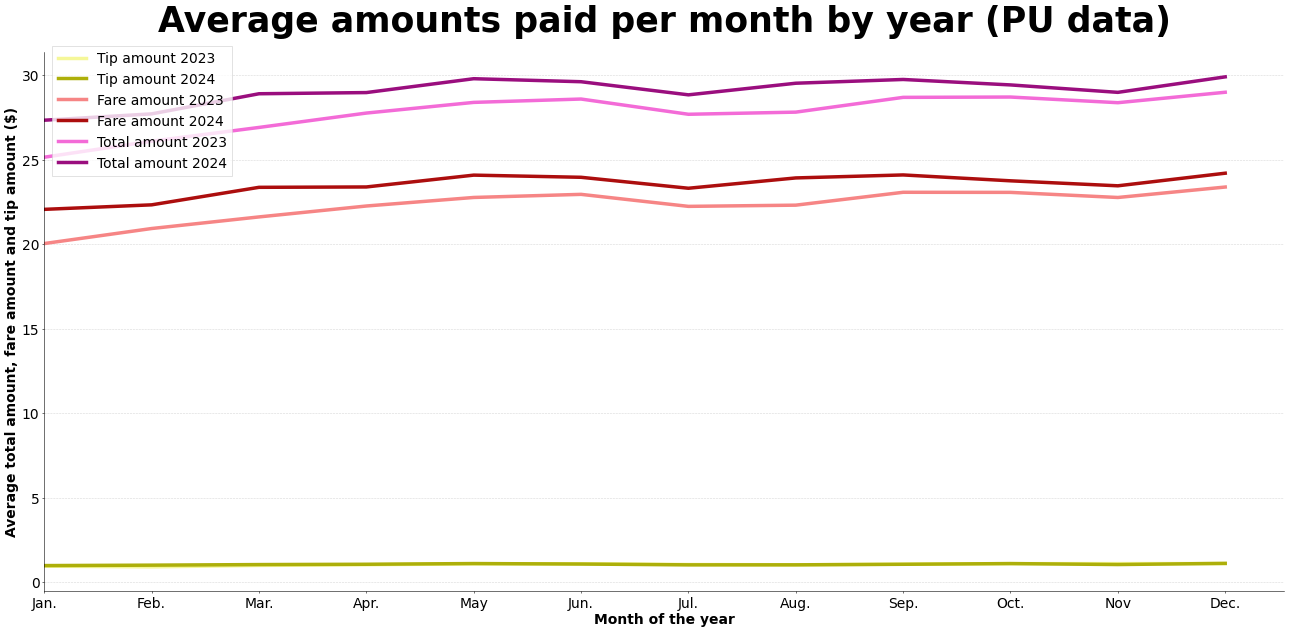

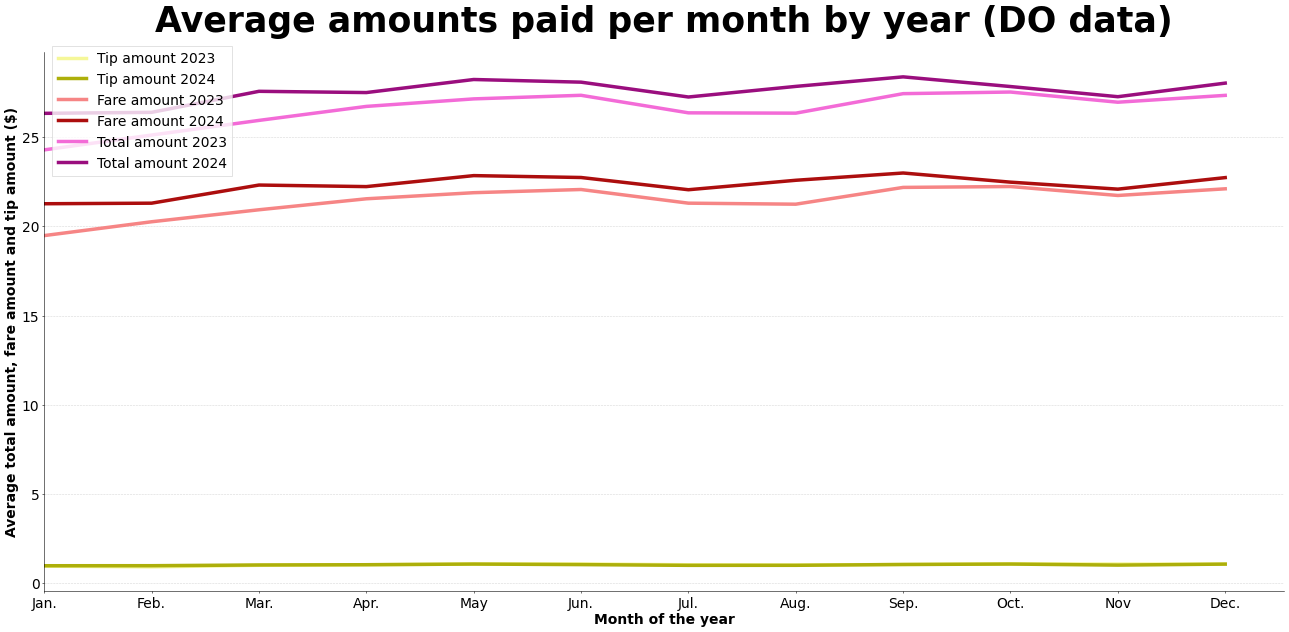

In [ ]:
PUs_df["PUhour"] = pd.to_datetime(PUs_df["PUhour"])
DOs_df["DOhour"] = pd.to_datetime(DOs_df["DOhour"])

monthly_amounts_PUs = PUs_df.groupby(["year","month"])[
    ["tip_amount","fare_amount","total_amount"]
].mean().reset_index()

monthly_amounts_DOs = DOs_df.groupby(["year","month"])[
    ["tip_amount","fare_amount","total_amount"]
].mean().reset_index()

melted_PUs = monthly_amounts_PUs.melt(
    id_vars=["year","month"],
    value_vars=["tip_amount","fare_amount","total_amount"],
    var_name="metric",
    value_name="amount"
)

melted_PUs["metric_year"] = melted_PUs["metric"] + melted_PUs["year"].astype(str)

melted_DOs = monthly_amounts_DOs.melt(
    id_vars=["year","month"],
    value_vars=["tip_amount","fare_amount","total_amount"],
    var_name="metric",
    value_name="amount"
)

melted_DOs["metric_year"] = melted_DOs["metric"] + melted_DOs["year"].astype(str)

palette = {
    "tip_amount2023": "#F5F799",
    "tip_amount2024": "#ADAF0A",
    "fare_amount2023": "#F68585",
    "fare_amount2024": "#AC0E0E",
    "total_amount2023": "#F36BD7",
    "total_amount2024": "#9A0E7E"
}

plt.figure(figsize=(32,14))

ax = sns.lineplot(
    data=melted_PUs,
    x="month",
    y="amount",
    hue="metric_year",
    markers=True,
    linewidth=5,
    palette=palette
)

plt.title("Average amounts paid per month by year (PU data)",
          fontsize=50, fontweight="bold",pad=30)
plt.grid(axis="y",linestyle="--", alpha=0.5)
plt.xlabel("Month of the year", fontweight="bold")
plt.ylabel("Average total amount, fare amount and tip amount ($)", fontweight="bold")
plt.xticks(range(1, 13),labels=
           ["Jan.","Feb.","Mar.","Apr.","May","Jun.","Jul.","Aug.","Sep.","Oct.","Nov","Dec."])
plt.xlim(left=1)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles=handles,
    labels=
    ["Tip amount 2023", "Tip amount 2024", "Fare amount 2023", "Fare amount 2024", "Total amount 2023", "Total amount 2024"],
    title="",
    title_fontproperties={"weight":"bold"},
    loc="upper left",
    bbox_to_anchor=(0.001,1.025),
    fancybox=False
)

plt.savefig("Plots\TimeSeries\Amounts\PUsAmountsMonthly.png",dpi=300)
plt.show()


plt.figure(figsize=(32,14))

ax = sns.lineplot(
    data=melted_DOs,
    x="month",
    y="amount",
    hue="metric_year",
    markers=True,
    linewidth=5,
    palette=palette
)

plt.title("Average amounts paid per month by year (DO data)",
          fontsize=50, fontweight="bold",pad=30)
plt.grid(axis="y",linestyle="--", alpha=0.5)
plt.xlabel("Month of the year", fontweight="bold")
plt.ylabel("Average total amount, fare amount and tip amount ($)", fontweight="bold")
plt.xticks(range(1, 13),labels=
           ["Jan.","Feb.","Mar.","Apr.","May","Jun.","Jul.","Aug.","Sep.","Oct.","Nov","Dec."])
plt.xlim(left=1)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles=handles,
    labels=
    ["Tip amount 2023", "Tip amount 2024", "Fare amount 2023", "Fare amount 2024", "Total amount 2023", "Total amount 2024"],
    title="",
    title_fontproperties={"weight":"bold"},
    loc="upper left",
    bbox_to_anchor=(0.001,1.025),
    fancybox=False
)

plt.savefig("Plots\TimeSeries\Amounts\DOsAmountsMonthly.png",dpi=300)
plt.show()

Amounts paid over a 7-day rolling average window

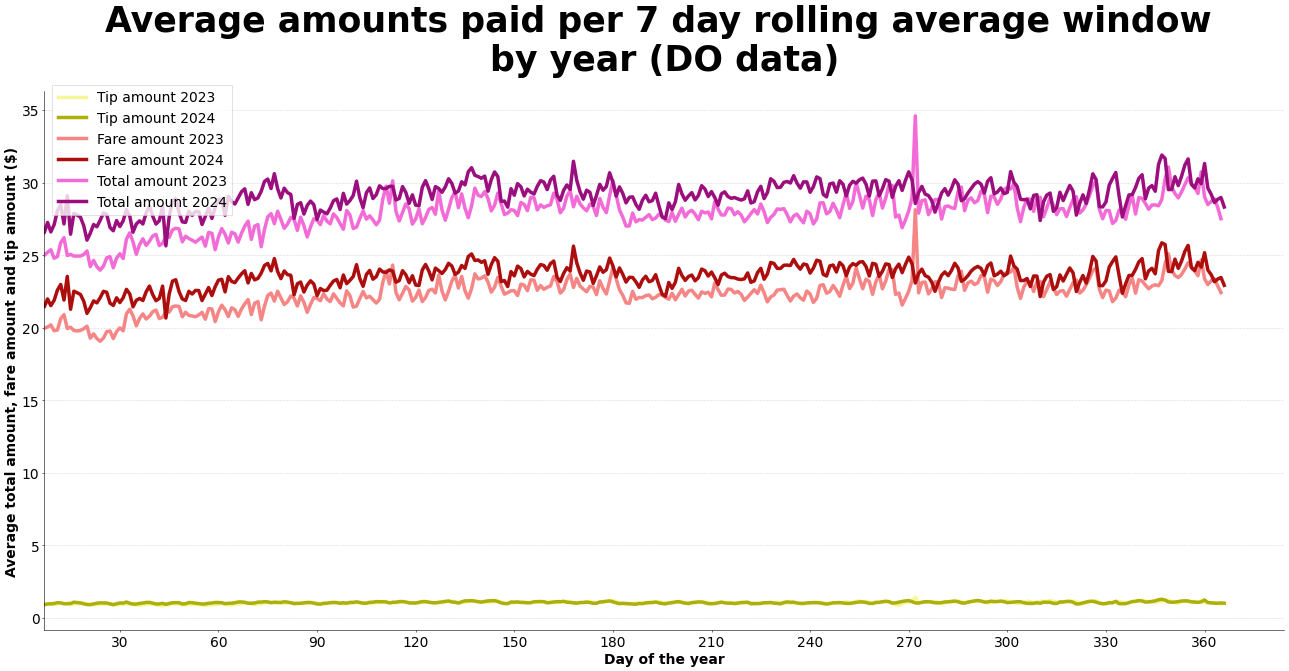

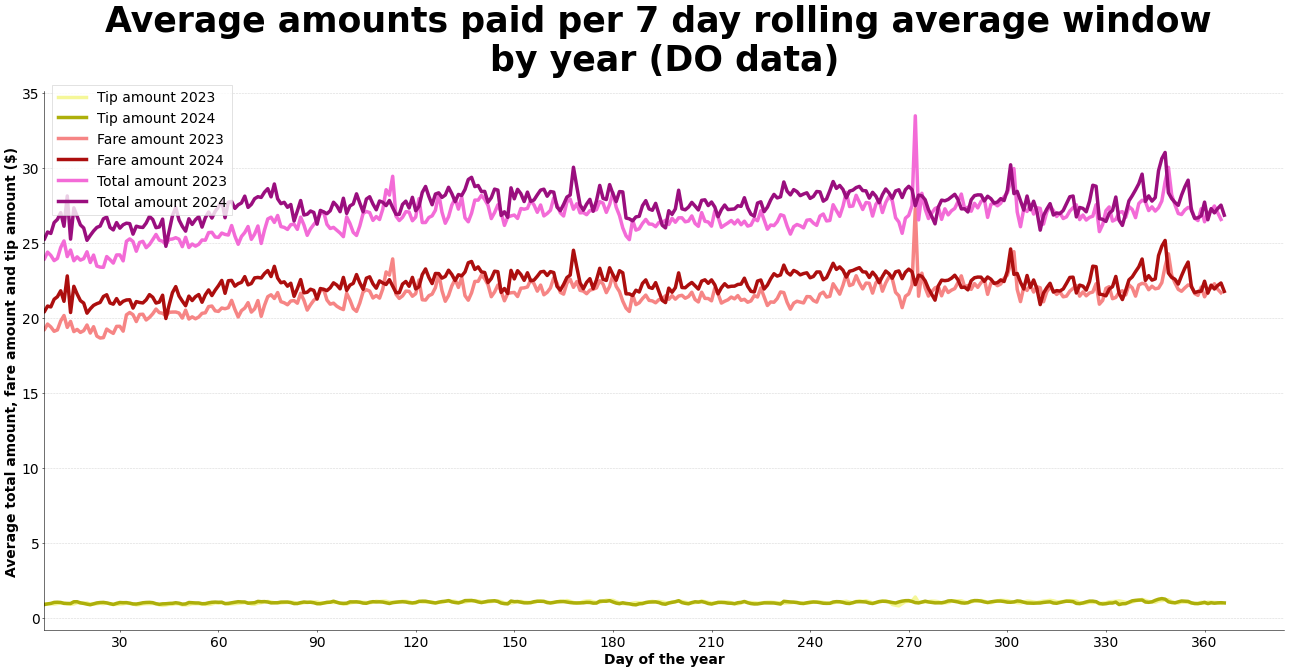

In [ ]:
PUs_df["PUhour"] = pd.to_datetime(PUs_df["PUhour"])
DOs_df["DOhour"] = pd.to_datetime(DOs_df["DOhour"])

daily_amounts_PUs = PUs_df.groupby(["PUhour"])[
    ["tip_amount","fare_amount","total_amount"]
].mean().reset_index()

daily_amounts_DOs = DOs_df.groupby(["DOhour"])[
    ["tip_amount","fare_amount","total_amount"]
].mean().reset_index()

daily_amounts_PUs["year"] = daily_amounts_PUs["PUhour"].dt.year
daily_amounts_PUs["DayOfYear"] = daily_amounts_PUs["PUhour"].dt.dayofyear

daily_amounts_DOs["year"] = daily_amounts_DOs["DOhour"].dt.year
daily_amounts_DOs["DayOfYear"] = daily_amounts_DOs["DOhour"].dt.dayofyear

melted_PUs = daily_amounts_PUs.melt(
    id_vars=["PUhour","year","DayOfYear"],
    value_vars=["tip_amount","fare_amount","total_amount"],
    var_name="metric",
    value_name="amount"
)

melted_PUs["metric_year"] = melted_PUs["metric"] + melted_PUs["year"].astype(str)


melted_DOs = daily_amounts_DOs.melt(
    id_vars=["DOhour","year","DayOfYear"],
    value_vars=["tip_amount","fare_amount","total_amount"],
    var_name="metric",
    value_name="amount"
)

melted_DOs["metric_year"] = melted_DOs["metric"] + melted_DOs["year"].astype(str)


melted_PUs["7dayAVG"] = melted_PUs.groupby(["metric", "year"])["amount"].transform(
    lambda x: x.rolling(window=7).mean()
)

melted_DOs["7dayAVG"] = melted_DOs.groupby(["metric", "year"])["amount"].transform(
    lambda x: x.rolling(window=7).mean()
)

palette = {
    "tip_amount2023": "#F5F799",
    "tip_amount2024": "#ADAF0A",
    "fare_amount2023": "#F68585",
    "fare_amount2024": "#AC0E0E",
    "total_amount2023": "#F36BD7",
    "total_amount2024": "#9A0E7E"
}

plt.figure(figsize=(32,14))

ax = sns.lineplot(
    data=melted_PUs,
    x="DayOfYear",
    y="7dayAVG",
    hue="metric_year",
    linewidth=5,
    palette=palette,
    errorbar=None
)

plt.title("Average amounts paid per 7 day rolling average window \nby year (DO data)",
          fontsize=50, fontweight="bold",pad=30)
plt.grid(axis="y",linestyle="--", alpha=0.5)
plt.xlabel("Day of the year", fontweight="bold")
plt.ylabel("Average total amount, fare amount and tip amount ($)", fontweight="bold")
plt.xticks(range(0,366,30))
plt.xlim(left=7)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles=handles,
    labels=
    ["Tip amount 2023", "Tip amount 2024", "Fare amount 2023", "Fare amount 2024", "Total amount 2023", "Total amount 2024"],
    title="",
    title_fontproperties={"weight":"bold"},
    loc="upper left",
    bbox_to_anchor=(0.001,1.025),
    fancybox=False
)

plt.savefig("Plots\TimeSeries\Amounts\PUsAmounts7DayAVG.png",dpi=300)
plt.show()

plt.figure(figsize=(32,14))

ax= sns.lineplot(
    data=melted_DOs,
    x="DayOfYear",
    y="7dayAVG",
    hue="metric_year",
    linewidth=5,
    palette=palette,
    errorbar=None
)

plt.title("Average amounts paid per 7 day rolling average window \nby year (DO data)",
          fontsize=50, fontweight="bold",pad=30)
plt.grid(axis="y",linestyle="--", alpha=0.5)
plt.xlabel("Day of the year", fontweight="bold")
plt.ylabel("Average total amount, fare amount and tip amount ($)", fontweight="bold")
plt.xticks(range(0,366,30))
plt.xlim(left=7)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles=handles,
    labels=
    ["Tip amount 2023", "Tip amount 2024", "Fare amount 2023", "Fare amount 2024", "Total amount 2023", "Total amount 2024"],
    title="",
    title_fontproperties={"weight":"bold"},
    loc="upper left",
    bbox_to_anchor=(0.001,1.025),
    fancybox=False
)

plt.savefig("Plots\TimeSeries\Amounts\DOsAmounts7DayAVG.png",dpi=300)
plt.show()


### Weather

Daily amount of rainfall and snowfall

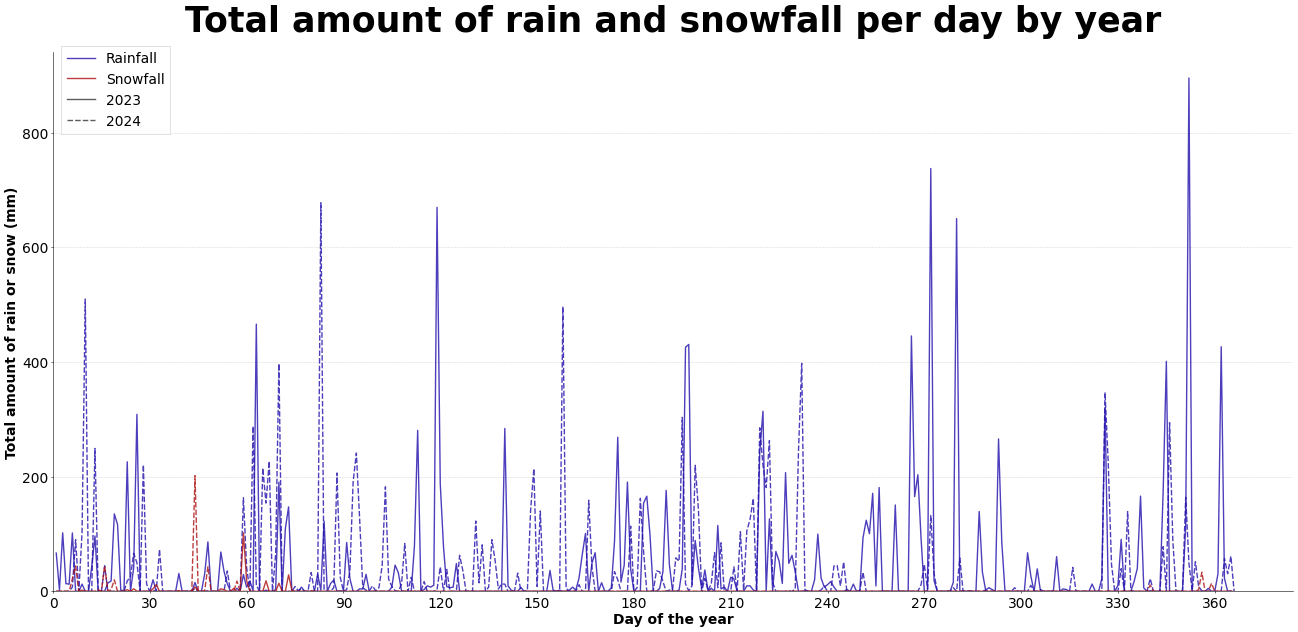

In [ ]:
daily_weather = PUs_df.groupby("PUhour")[["rain","snowfall"]].sum().reset_index()
daily_weather["year"] = daily_weather["PUhour"].dt.year
daily_weather["DayOfYear"] = daily_weather["PUhour"].dt.dayofyear

melted_weather = daily_weather.melt(
    id_vars=["PUhour","year","DayOfYear"],
    value_vars=["rain","snowfall"],
    var_name="metric",
    value_name="amount"
)

melted_weather["metric"] = melted_weather["metric"].replace({
    "rain": "Rainfall", 
    "snowfall": "Snowfall"
})

palette = {
    "Rainfall": "#200EAC",
    "Snowfall": "#AC0E0E",
}

plt.figure(figsize=(32,14))

ax = sns.lineplot(
    data=melted_weather,
    x="DayOfYear",
    y="amount",
    hue="metric",
    style="year",
    palette=palette,
    linewidth=2,
    alpha=0.8,
    errorbar=None
)

handles, labels = ax.get_legend_handles_labels()

new_handles = []
new_labels = []

for handle, label in zip(handles, labels):
    if str(label).lower() not in ["year", "metric"]:  
        new_handles.append(handle)
        new_labels.append(label)

if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.legend(
    handles=new_handles,
    labels=new_labels,
    loc="upper left",
    bbox_to_anchor=(0.001, 1.025),
    fancybox=False
)

plt.title("Total amount of rain and snowfall per day by year",
          fontsize=50, fontweight="bold",pad=30)
plt.grid(axis="y",linestyle="--", alpha=0.5)
plt.xlabel("Day of the year", fontweight="bold")
plt.ylabel("Total amount of rain or snow (mm)", fontweight="bold")
plt.xticks(range(0,366,30))
plt.xlim(left=0)
plt.ylim(bottom=0)

plt.savefig("Plots\TimeSeries\Weather\RainAndSnowDaily.png",dpi=300)
plt.show()

Apparent temperature and snow depth by day

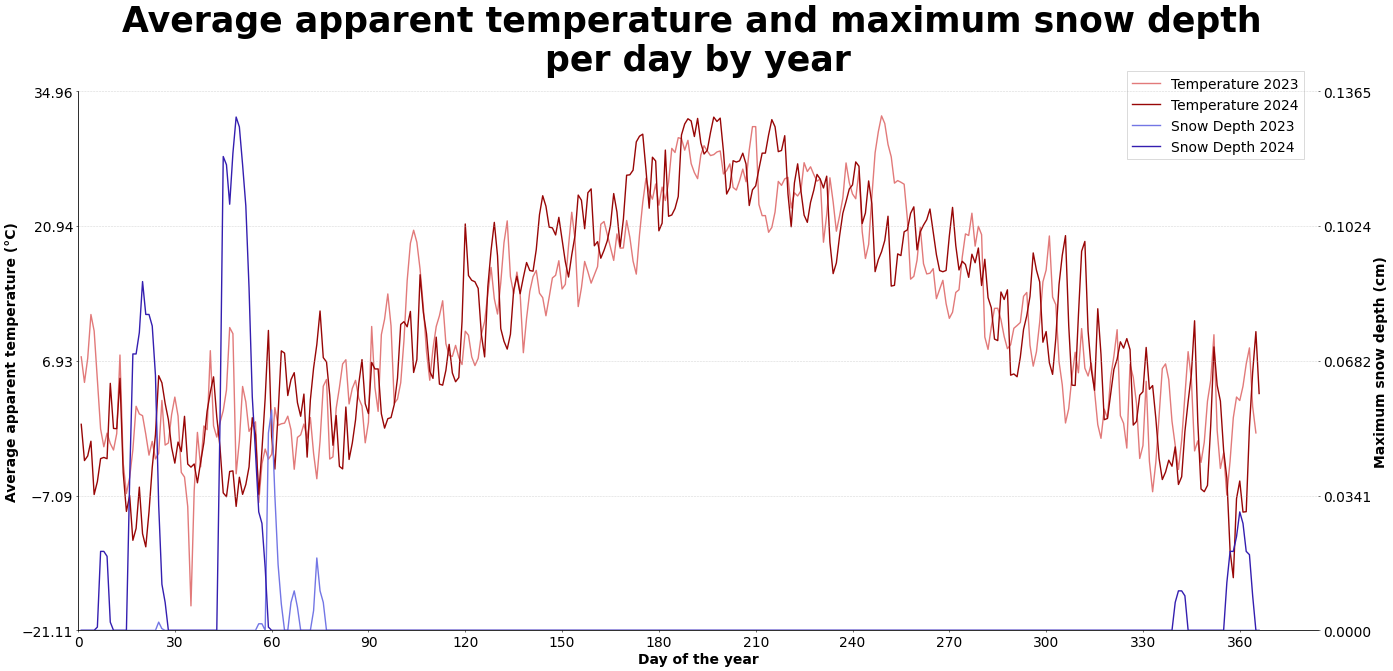

In [ ]:
daily_df = PUs_df.groupby("PUhour").agg({
    "apparent_temperature": "mean",
    "snow_depth":"max"
}).reset_index()

daily_df["year"] = daily_df["PUhour"].dt.year.astype(str)
daily_df["DayOfYear"] = daily_df["PUhour"].dt.dayofyear

daily_df["7DayTemp"] = daily_df.groupby("year")["apparent_temperature"].transform(
    lambda x: x.rolling(window=7).mean()
)

fig, ax1 = plt.subplots(figsize=(32, 14))

sns.lineplot(
    data=daily_df, 
    x="DayOfYear", 
    y="7DayTemp", 
    hue="year", 
    ax=ax1,
    palette={"2023": "#e27a7a", "2024": "#980606"},
    linewidth=2,
    legend=False,
    errorbar=None 
)

plt.ylabel("Average apparent temperature (°C)", fontweight="bold")
plt.xlabel("Day of the year", fontweight="bold")
plt.xlim(left=0)

ax2 = ax1.twinx()

sns.lineplot(
    data=daily_df, 
    x="DayOfYear", 
    y="snow_depth", 
    hue="year", 
    ax=ax2,
    palette={"2023": "#7376e5", "2024": "#341eb0"},
    linewidth=2,
    legend=False,
    errorbar=None 
)

plt.title("Average apparent temperature and maximum snow depth \nper day by year",
          fontsize=50, fontweight="bold",pad=30)
plt.grid(axis="y",linestyle="--", alpha=0.5)
plt.ylabel("Maximum snow depth (cm)", fontweight="bold")
plt.xticks(range(0,366,30))
plt.ylim(bottom=0)
ax1.yaxis.set_major_locator(ticker.LinearLocator(5))
ax2.yaxis.set_major_locator(ticker.LinearLocator(5))

custom_handles = [
    Line2D([0], [0], color="#e27a7a", lw=2),
    Line2D([0], [0], color="#980606", lw=2),
    Line2D([0], [0], color="#7376e5", lw=2),
    Line2D([0], [0], color="#341eb0", lw=2)
]

custom_labels = [
    "Temperature 2023",
    "Temperature 2024",
    "Snow Depth 2023",
    "Snow Depth 2024"
]

ax1.legend(
    handles=custom_handles,
    labels=custom_labels,
    loc="upper left",
    bbox_to_anchor=(0.84, 1.05),
    fancybox=False,
    framealpha=1
)

plt.savefig("Plots\TimeSeries\Weather\TempAndSnow_depthDaily.png",dpi=300)
plt.show()